# <center> **News Category Classification Using** </center>
----

- This notebook demonstrates an end-to-end machine learning pipeline for classifying news articles into predefined categories. The pipeline covers data loading, cleaning, exploratory data analysis (EDA), text preprocessing, model training, and evaluation. The dataset used is a synthetic, uncleaned dataset generated to simulate real-world data challenges.

- **Categories:** `Sports`, `Business`, `Politics`, `Technology`, `Entertainment`

- **Libraries Used:** `Pandas`, `NumPy`, `Matplotlib`, `Seaborn`, `Scikit-learn`, `NLTK`

#### Step 01: Setup and Library Installation

In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn nltk

#### Step 02: Download NLTK Stopwords

In [ ]:
import nltk
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

#### Step 03: Import libraries

In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

#### Step 04: Load Data

In [9]:
print("Loading data...")
df = pd.read_csv('news_category_dataset_uncleaned.csv')
print(f"Initial dataset shape: {df.shape}")

Loading data...
Initial dataset shape: (680, 2)


### <center> **Data Cleaning and Preprocessing** </center>
---

#### Step 01: Handle missing values

In [10]:
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(subset=['text', 'category'], inplace=True)
print(f"Missing values after cleaning:\n{df.isnull().sum()}")
print(f"Dataset shape after dropping NaNs: {df.shape}")

Missing values before cleaning:
text        21
category     0
dtype: int64
Missing values after cleaning:
text        0
category    0
dtype: int64
Dataset shape after dropping NaNs: (659, 2)


#### Step 02: Standardize category labels (e.g., '`sports`', '`Sports`', '`SPORTS`' -> '`Sports`')

In [11]:
df['category'] = df['category'].str.capitalize()
print(f"Unique categories after standardization: {df['category'].unique()}")

Unique categories after standardization: ['Entertainment' 'Technology' 'Sports' 'Politics' 'Business']


#### Step 03: Remove HTML tags

In [12]:
def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

df['text'] = df['text'].apply(remove_html_tags)

#### Step 04: Normalize case (already handled by capitalize for categories, but ensure for text)

In [13]:
df['text'] = df['text'].str.lower()

#### Step 05: Remove extra whitespace

In [14]:
df['text'] = df['text'].str.strip()
df['text'] = df['text'].apply(lambda x: re.sub(r'\s+', ' ', x))

#### Step 06: Clean punctuation/special characters (keep only alphanumeric and spaces)

In [15]:
df['text'] = df['text'].apply(lambda x: re.sub(r'[^a-z0-9\s]', '', x))

#### Step 07: Handle duplicates

In [16]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")
print(f"Dataset shape after dropping duplicates: {df.shape}")

Number of duplicate rows before dropping: 288
Number of duplicate rows after dropping: 0
Dataset shape after dropping duplicates: (371, 2)


### <center> **Exploratory Data Analysis (EDA)** </center>
---

#### Step 01: Visualize category distribution

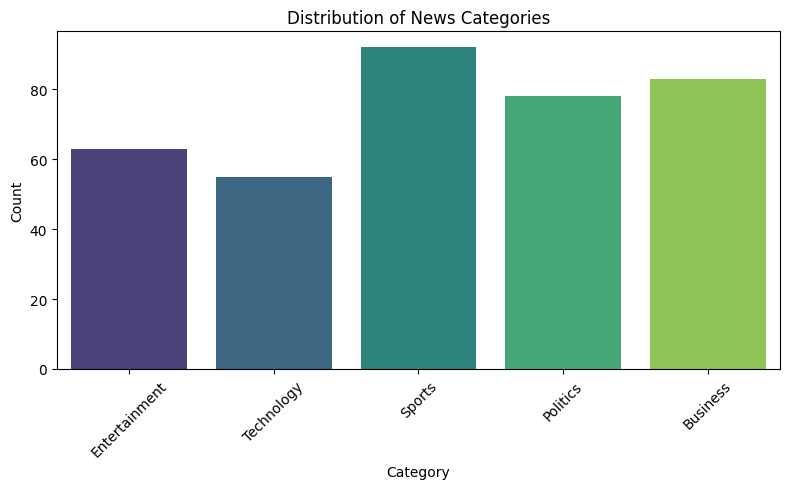

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='category', palette='viridis')
plt.title('Distribution of News Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

#### Step 02: Analyze text length distribution

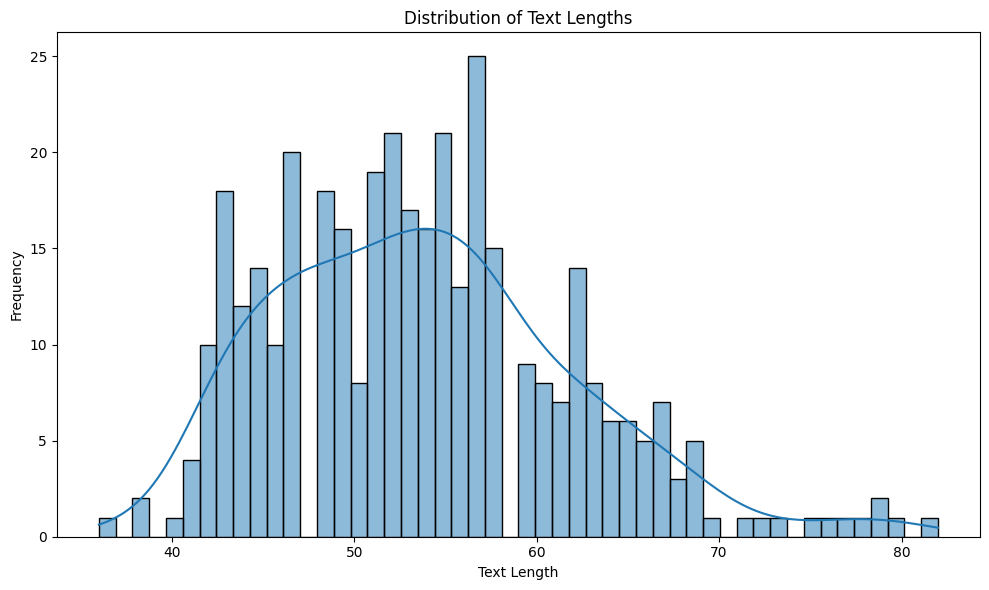

In [18]:

df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.tight_layout()

### <center> **Text Preprocessing for ML** </center>
---

#### Step 01: Remove stopwords

In [19]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word not in stop_words])

df['text_cleaned'] = df['text'].apply(remove_stopwords)

####  Step 03: Vectorization (TF-IDF)

In [20]:
vectorizer = TfidfVectorizer(max_features=5000) # Limit features to 5000 for simplicity
X = vectorizer.fit_transform(df['text_cleaned'])
y = df['category']

print(f"Shape of TF-IDF matrix: {X.shape}")

Shape of TF-IDF matrix: (371, 375)


### <center> **Model Training** </center>
---

#### Step 01: Split data into training and testing sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")

Training data shape: (296, 375), Test data shape: (75, 375)


#### Step 02: Train a classifier (Multinomial Naive Bayes)

In [22]:
model = MultinomialNB()
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


### <center> **Model Evaluation** </center>
---

#### Step 01: Make Predictions

In [23]:
y_pred = model.predict(X_test)

#### Step 02: Classification Report

In [24]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

     Business       1.00      1.00      1.00        17
Entertainment       1.00      1.00      1.00        13
     Politics       1.00      1.00      1.00        16
       Sports       1.00      1.00      1.00        18
   Technology       1.00      1.00      1.00        11

     accuracy                           1.00        75
    macro avg       1.00      1.00      1.00        75
 weighted avg       1.00      1.00      1.00        75



#### Step 03: Confusion Matrix

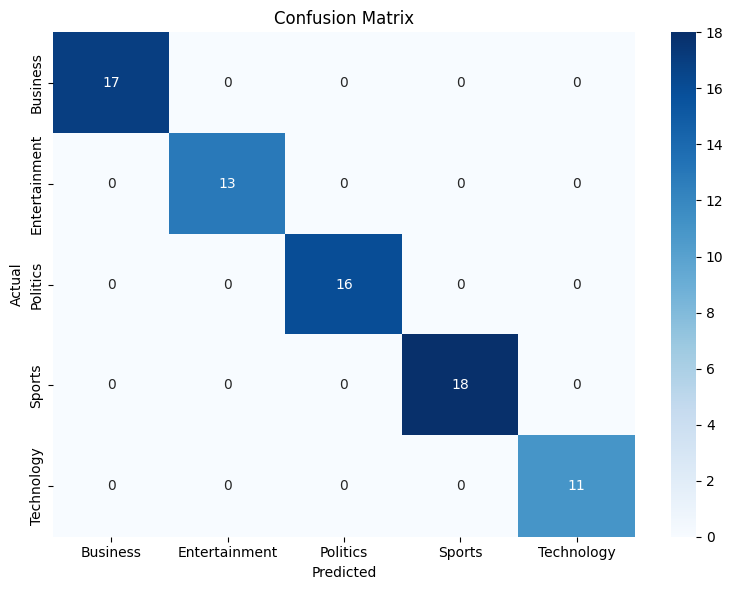

In [26]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()